In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('13-car_evaluation.csv')

In [3]:
df.head()

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [4]:
df.columns = ['price' , 'maint' , 'doors' , 'persons' , 'lug_boot' , 'safety' , 'class']

In [5]:
df.head()

,price,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   price     1727 non-null   object
 1   maint     1727 non-null   object
 2   doors     1727 non-null   object
 3   persons   1727 non-null   object
 4   lug_boot  1727 non-null   object
 5   safety    1727 non-null   object
 6   class     1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [7]:
df.isnull().sum()

price       0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

In [8]:
for col in df.columns : 
    print(df[col].value_counts())

price
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
maint
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
doors
3        432
4        432
5more    432
2        431
Name: count, dtype: int64
persons
4       576
more    576
2       575
Name: count, dtype: int64
lug_boot
med      576
big      576
small    575
Name: count, dtype: int64
safety
med     576
high    576
low     575
Name: count, dtype: int64
class
unacc    1209
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [9]:
df['doors']  = df['doors'].str.replace('5more' , '5')
df['persons'] = df['persons'].str.replace('more' , '5')

In [10]:
df['doors'] = df['doors'].astype(int)
df['persons'] = df['persons'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   price     1727 non-null   object
 1   maint     1727 non-null   object
 2   doors     1727 non-null   int64 
 3   persons   1727 non-null   int64 
 4   lug_boot  1727 non-null   object
 5   safety    1727 non-null   object
 6   class     1727 non-null   object
dtypes: int64(2), object(5)
memory usage: 94.6+ KB


In [11]:
from sklearn.model_selection import train_test_split

X = df.drop(columns = 'class' , axis = 1)
y = df['class']

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.25 , random_state = 15)

from sklearn.preprocessing import OrdinalEncoder

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [13]:
categorial_cols = ['price' , 'maint' , 'lug_boot' , 'safety']
numerical_cols = ['doors' , 'persons']
ordinal_encoder = OrdinalEncoder(categories = [
        ['low' , 'med' , 'high' , 'vhigh'], # Buying
        ['low' , 'med' , 'high' , 'vhigh'], # Maint
        ['small', 'med' , 'big'], # Lug_boot
        ['low' , 'med' , 'high'] # Safetiy
])

preprocessor = ColumnTransformer(
    transformers = [
        ('Name' , ordinal_encoder , categorial_cols)
        # , ('Name' , 'Encoder' , 'List') # Bu şekilde birden fazla kolona seçtiğimiz encoder ile işlem yapabilirz
    ],
    remainder = 'passthrough' 
)

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [14]:
X_test_transformed

array([[3., 1., 2., 1., 4., 4.],
       [1., 0., 2., 2., 5., 5.],
       [1., 0., 0., 2., 4., 2.],
       ...,
       [1., 1., 2., 1., 2., 4.],
       [0., 3., 1., 2., 3., 4.],
       [3., 2., 0., 0., 2., 4.]])

In [15]:
pd.DataFrame(X_test_transformed)

,0,1,2,3,4,5
0,3.0,1.0,2.0,1.0,4.0,4.0
1,1.0,0.0,2.0,2.0,5.0,5.0
2,1.0,0.0,0.0,2.0,4.0,2.0
3,3.0,1.0,1.0,0.0,2.0,2.0
4,3.0,1.0,2.0,2.0,5.0,4.0
...,...,...,...,...,...,...
427,3.0,3.0,2.0,0.0,3.0,2.0
428,2.0,2.0,1.0,1.0,5.0,5.0
429,1.0,1.0,2.0,1.0,2.0,4.0
430,0.0,3.0,1.0,2.0,3.0,4.0


In [16]:
from sklearn.tree import DecisionTreeClassifier

In [17]:
tree_model = DecisionTreeClassifier(criterion = 'gini' , splitter = 'best' , max_depth = None) 

In [18]:
tree_model.fit(X_train_transformed , y_train)
y_pred = tree_model.predict(X_test_transformed) 

from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

print('Classification Report \n' , classification_report(y_test , y_pred))
print('Confusion Matrix : \n' , confusion_matrix(y_test , y_pred))


Classification Report 
               precision    recall  f1-score   support

         acc       0.95      0.98      0.96        93
        good       1.00      0.84      0.91        19
       unacc       1.00      0.99      1.00       305
       vgood       0.94      1.00      0.97        15

    accuracy                           0.98       432
   macro avg       0.97      0.95      0.96       432
weighted avg       0.98      0.98      0.98       432

Confusion Matrix : 
 [[ 91   0   1   1]
 [  3  16   0   0]
 [  2   0 303   0]
 [  0   0   0  15]]


[Text(0.25, 0.9, 'safety <= 0.5\ngini = 0.459\nsamples = 1295\nvalue = [291, 50, 904, 50]'),
 Text(0.125, 0.7, 'gini = 0.0\nsamples = 436\nvalue = [0, 0, 436, 0]'),
 Text(0.1875, 0.8, 'True  '),
 Text(0.375, 0.7, 'persons <= 3.0\ngini = 0.582\nsamples = 859\nvalue = [291.0, 50.0, 468.0, 50.0]'),
 Text(0.3125, 0.8, '  False'),
 Text(0.25, 0.5, 'gini = 0.0\nsamples = 281\nvalue = [0, 0, 281, 0]'),
 Text(0.5, 0.5, 'price <= 1.5\ngini = 0.627\nsamples = 578\nvalue = [291.0, 50.0, 187.0, 50.0]'),
 Text(0.25, 0.3, 'maint <= 1.5\ngini = 0.639\nsamples = 298\nvalue = [160, 50, 38, 50]'),
 Text(0.125, 0.1, '\n  (...)  \n'),
 Text(0.375, 0.1, '\n  (...)  \n'),
 Text(0.75, 0.3, 'maint <= 2.5\ngini = 0.498\nsamples = 280\nvalue = [131, 0, 149, 0]'),
 Text(0.625, 0.1, '\n  (...)  \n'),
 Text(0.875, 0.1, '\n  (...)  \n')]

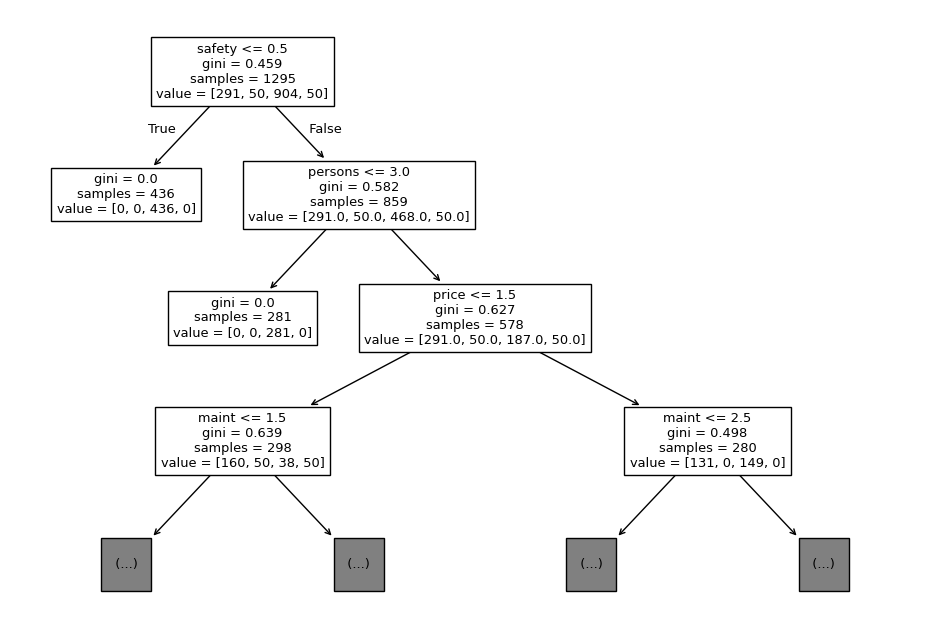

In [19]:
# Agac Gorsellestirme
plt.figure(figsize = (12 , 8))

from sklearn import tree
columns = categorial_cols + numerical_cols
tree.plot_tree(decision_tree = tree_model.fit(X_train_transformed , y_train) , max_depth = 3 , feature_names = columns)

In [20]:
# Hyperparamether Tuining

In [21]:
params = {
    'criterion'  : ['gini' , 'entropy' , 'log_loss'],
    'splitter'  : ['best' , 'random' ] , 
    'max_depth' : [4 , 5 , 7,  8 , 10 , 13 , 16 , 18 , None],
    'max_features' : ['sqrt' , 'log2' , None]
}

In [22]:
from sklearn.model_selection import GridSearchCV , StratifiedKFold

cv = StratifiedKFold(n_splits=5)

In [23]:
grid = GridSearchCV(estimator = tree_model , param_grid = params , scoring = 'accuracy' , n_jobs = -1 , cv = cv , verbose = 5 )

In [24]:
grid.fit(X_train_transformed , y_train)

Fitting 5 folds for each of 162 candidates, totalling 810 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [4, 5, 7, 8, 10, 13, 16, 18, None],
                         'max_features': ['sqrt', 'log2', None],
                         'splitter': ['best', 'random']},
             scoring='accuracy', verbose=5)

In [25]:
y_pred_grid = grid.predict(X_test_transformed)

print('Classification Report \n' , classification_report(y_test , y_pred))
print('Confusion Matrix : \n' , confusion_matrix(y_test , y_pred))


Classification Report 
               precision    recall  f1-score   support

         acc       0.95      0.98      0.96        93
        good       1.00      0.84      0.91        19
       unacc       1.00      0.99      1.00       305
       vgood       0.94      1.00      0.97        15

    accuracy                           0.98       432
   macro avg       0.97      0.95      0.96       432
weighted avg       0.98      0.98      0.98       432

Confusion Matrix : 
 [[ 91   0   1   1]
 [  3  16   0   0]
 [  2   0 303   0]
 [  0   0   0  15]]


In [26]:
# ---------------------------------------------------- DECISION TREE REGRESSION ----------------------------------------------------------------------

In [27]:
df = pd.read_csv('13-)house_price_regression_dataset.csv')
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [28]:
df['House_Price'] = df['House_Price'] / 1000

In [29]:
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,262.382852
1,4272,3,3,2016,4.753014,1,6,985.260854
2,3592,1,2,2016,3.634823,0,9,777.977390
3,966,1,2,1977,2.730667,1,8,229.698919
4,4926,2,1,1993,4.699073,0,8,1041.740859


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [49]:
X = df.drop(columns = ['House_Price'] , axis = 1)
y = df['House_Price']

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.3 , random_state = 10)

In [50]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.tree import DecisionTreeRegressor
reg_tree = DecisionTreeRegressor(max_depth = 4 , min_samples_leaf = 7 , random_state = 10 )
reg_tree.fit(X_train_scaled , y_train)

y_pred = reg_tree.predict(X_test_scaled)
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score
print('R2 Score : ',r2_score(y_test , y_pred))
print('MAE : ' , mean_absolute_error(y_test , y_pred))
print('MSE : ',mean_squared_error(y_test , y_pred))

R2 Score :  0.9737096391302952
MAE :  31.1594978674073
MSE :  1604.7803725815916


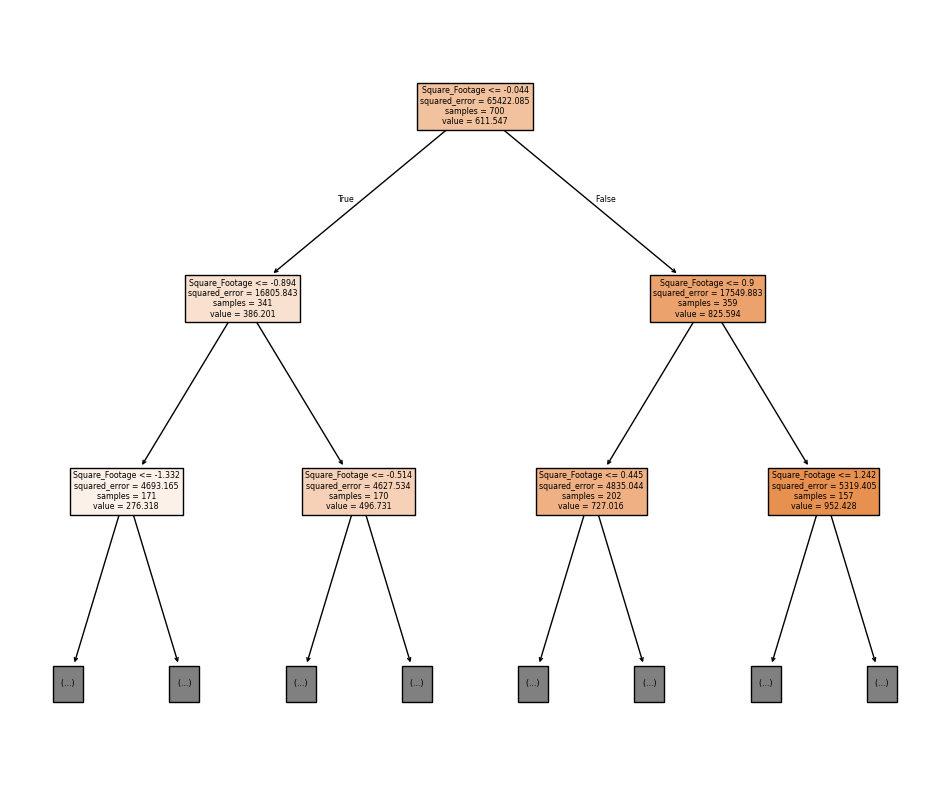

In [51]:
plt.figure(figsize = (12 , 10 ))

tree.plot_tree(reg_tree.fit(X_train_scaled , y_train) , filled = True , feature_names = df.columns , max_depth = 2)
plt.show()

In [52]:
# Eğitim seti skoru (Muhtemelen 1.0 çıkacak)
train_score = reg_tree.score(X_train_scaled, y_train)

# Test seti skoru (Senin sonucun: 0.98)
test_score = reg_tree.score(X_test_scaled, y_test)

print(f"Train Score: {train_score}")
print(f"Test Score: {test_score}")

Train Score: 0.9832182313293649
Test Score: 0.9737096391302952


In [55]:
reg_tree.feature_importances_# YAPAY BİR VERİ SETİDİR 

array([1., 0., 0., 0., 0., 0., 0.])

In [56]:
# GERCEK VERİYE GECELİM

In [57]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
import matplotlib.pyplot as plt

# 1. Gerçek Veriyi Yükle
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # Ev fiyatları (100.000$ biriminden)

# 2. Eğitim ve Test olarak ayır
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Modeli Kur (Hafif frenli: Derinlik sınırı 5)
reg_tree = DecisionTreeRegressor(max_depth=5, random_state=42)
reg_tree.fit(X_train, y_train)

# 4. Tahmin ve Skor
y_pred = reg_tree.predict(X_test)
train_pred = reg_tree.predict(X_train)

print(f"Test R2 Skoru : {r2_score(y_test, y_pred):.3f}")
print(f"Train R2 Skoru: {r2_score(y_train, train_pred):.3f}") # Overfitting kontrolü için
print("-" * 30)

# 5. ASIL MERAK ETTİĞİMİZ KISIM: Hangi özellik önemli?
importances = pd.Series(reg_tree.feature_importances_, index=X.columns)
print("Gerçek Dünyada Feature Importance Dağılımı:")
print(importances.sort_values(ascending=False))

Test R2 Skoru : 0.600
Train R2 Skoru: 0.638
------------------------------
Gerçek Dünyada Feature Importance Dağılımı:
MedInc        0.771212
AveOccup      0.128407
HouseAge      0.041621
AveRooms      0.031261
Latitude      0.022049
Population    0.002485
Longitude     0.002097
AveBedrms     0.000869
dtype: float64
